# Customer Segmentation Analysis

## Oasis Infobyte Internship

**Name:** Prince Kumar  
**Track:** Data Analytics  
**Level:** Level 1  
**Task:** Task 2 - Customer Segmentation Analysis  

---

## Objective

The objective of this project is to apply clustering algorithms
to segment an e-commerce company's customer base into distinct
groups based on purchasing behaviour, enabling targeted marketing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [3]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268


In [9]:
# Make a copy of the original dataset
df_clean = df.copy()

# Convert InvoiceNo to string
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)

# Remove cancelled invoices
df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C")]

# Remove rows with missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Keep only valid Quantity and UnitPrice
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
]

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Calculate total purchase amount
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_clean.shape)

Original Dataset Shape: (541909, 8)
Cleaned Dataset Shape: (392692, 9)


In [10]:
# Check cleaned dataset
print("Missing Values After Cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df_clean.duplicated().sum())

print("\nCleaned Dataset Preview:")
display(df_clean.head())

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate Rows After Cleaning:
0

Cleaned Dataset Preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
# Create customer-level purchase summary

customer_summary = df_clean.groupby("CustomerID").agg(
    Total_Purchase_Value=("TotalAmount", "sum"),
    Purchase_Frequency=("InvoiceNo", "nunique")
).reset_index()

# Calculate average purchase value
customer_summary["Average_Purchase_Value"] = (
    customer_summary["Total_Purchase_Value"] /
    customer_summary["Purchase_Frequency"]
)

# Historical customer lifetime value
customer_summary["Customer_Lifetime_Value"] = (
    customer_summary["Total_Purchase_Value"]
)

# Display summary
display(customer_summary.head())

,CustomerID,Total_Purchase_Value,Purchase_Frequency,Average_Purchase_Value,Customer_Lifetime_Value
0,12346.0,77183.60,1,77183.600000,77183.60
1,12347.0,4310.00,7,615.714286,4310.00
2,12348.0,1797.24,4,449.310000,1797.24
3,12349.0,1757.55,1,1757.550000,1757.55
4,12350.0,334.40,1,334.400000,334.40


In [12]:
# Set reference date as one day after the last transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM features for each customer
rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

# Display RFM data
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [13]:
# Descriptive statistics of RFM features
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


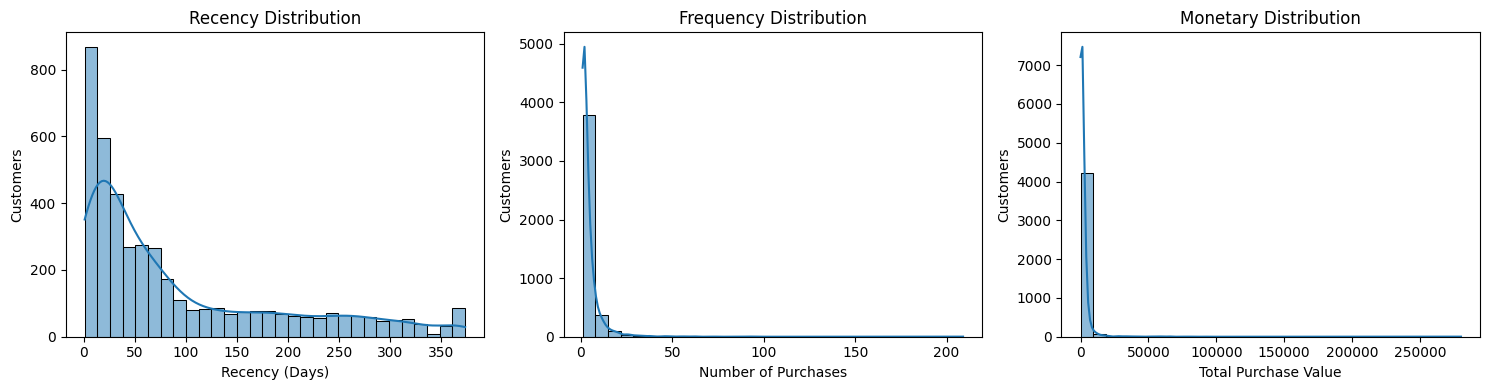

In [14]:
# Visualize RFM feature distributions

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm["Recency"], bins=30, kde=True)
plt.title("Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Customers")

plt.subplot(1, 3, 2)
sns.histplot(rfm["Frequency"], bins=30, kde=True)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Customers")

plt.subplot(1, 3, 3)
sns.histplot(rfm["Monetary"], bins=30, kde=True)
plt.title("Monetary Distribution")
plt.xlabel("Total Purchase Value")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

In [15]:
# Select RFM features for clustering
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize the RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data into a DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

# Display standardized data
display(rfm_scaled_df.head())

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


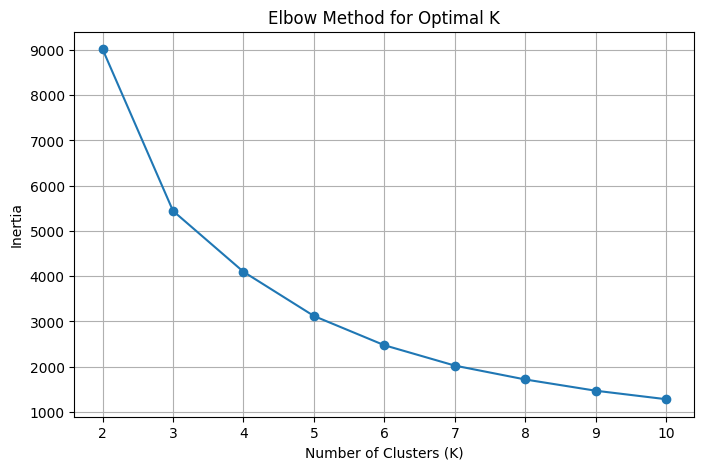

In [16]:
# Find the optimal number of clusters using the Elbow Method

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [18]:
# Apply K-Means clustering

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Create cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display customers with their cluster
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [19]:
# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [20]:
# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1353.63
1,1067,248.08,1.55,478.85
2,13,7.38,82.54,127187.96
3,204,15.50,22.33,12690.50


In [21]:
# Assign meaningful names to customer segments

segment_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Loyal High-Value Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(segment_names)

# Display segment distribution
display(
    rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Customer_Segment"]].head()
)

,CustomerID,Recency,Frequency,Monetary,Customer_Segment
0,12346.0,326,1,77183.60,Loyal High-Value Customers
1,12347.0,2,7,4310.00,Regular Customers
2,12348.0,75,4,1797.24,Regular Customers
3,12349.0,19,1,1757.55,Regular Customers
4,12350.0,310,1,334.40,At-Risk Customers


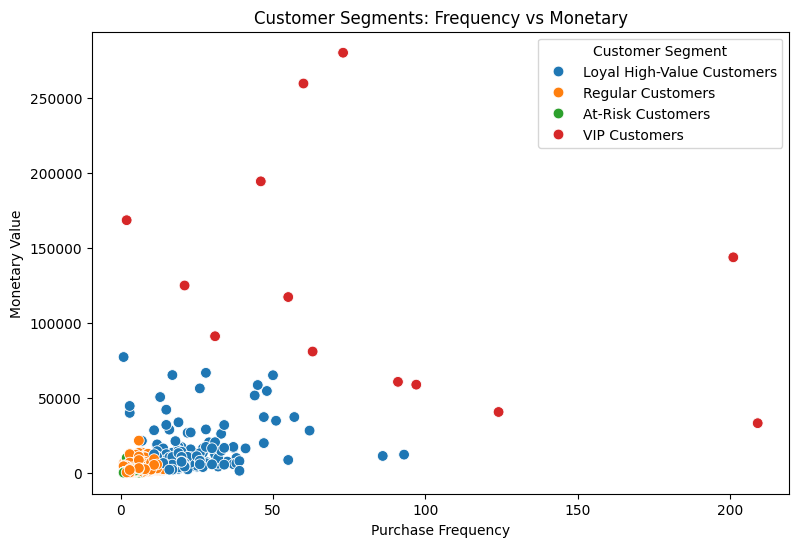

In [22]:
# Scatter plot: Frequency vs Monetary

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Customer_Segment",
    s=60
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")
plt.show()

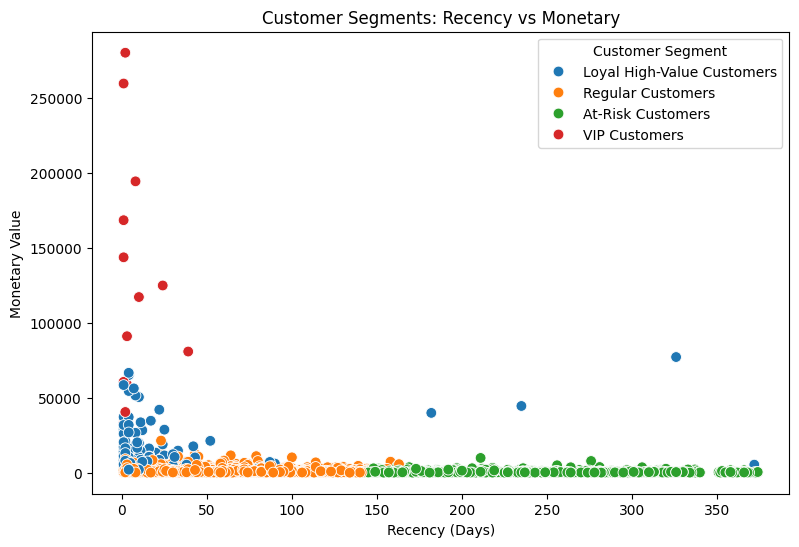

In [23]:
# Scatter plot: Recency vs Monetary

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Customer_Segment",
    s=60
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")
plt.show()

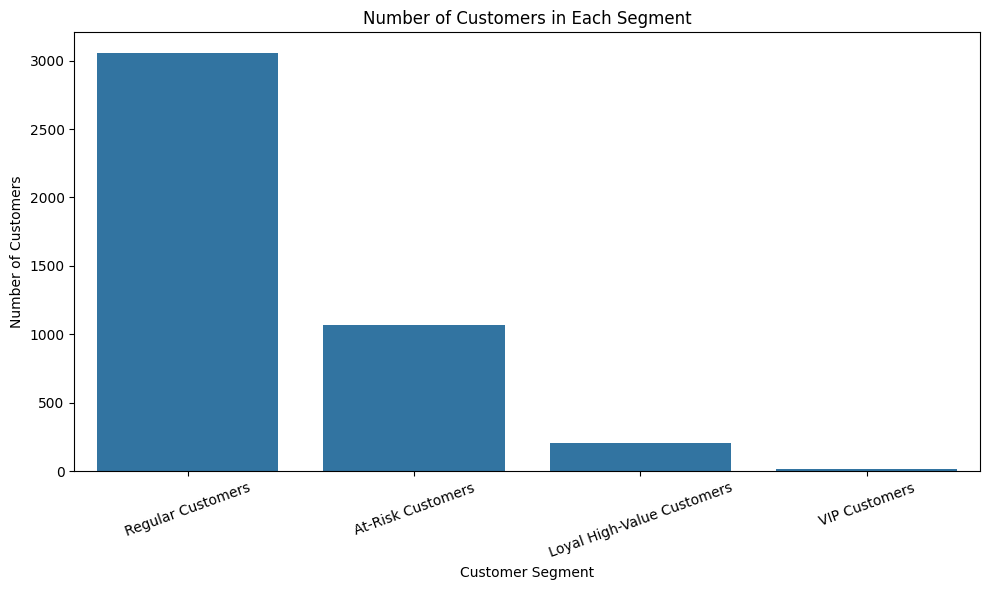

In [24]:
# Count customers in each segment

segment_counts = rfm["Customer_Segment"].value_counts()

# Plot customer count by segment
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [25]:
# Create final customer segment profile

final_profile = rfm.groupby("Customer_Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(final_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Customer_Segment,,,,
At-Risk Customers,1067,248.08,1.55,478.85
Loyal High-Value Customers,204,15.50,22.33,12690.50
Regular Customers,3054,43.70,3.68,1353.63
VIP Customers,13,7.38,82.54,127187.96


## Marketing Recommendations

1. Regular Customers
These customers make purchases regularly but have moderate purchase frequency and spending.

Recommended Action:
  - Offer personalized discounts
  - Recommend related products
  - Encourage repeat purchases through loyalty rewards

2. At-Risk Customers
These customers have not purchased recently and have relatively low purchase frequency and spending.

 Recommended Action:
  - Send re-engagement emails
  - Provide limited-time discount offers
  - Use personalized product recommendations to encourage a return purchase


3. VIP Customers
These customers have very high purchase frequency and monetary value and have purchased recently.

Recommended Action:
  - Provide VIP loyalty benefits
  - Offer exclusive products and early access
  - Give personalized rewards and premium customer support

4. Loyal High-Value Customers
These customers purchase frequently, spend significantly, and have made recent purchases.


Recommended Action:
  - Strengthen loyalty through reward programs
  - Provide targeted premium offers
  - Encourage referrals and repeat purchases

## Key Insights

- The customer base was successfully segmented into four distinct groups using K-Means clustering based on Recency, Frequency, and Monetary (RFM) features.

- Regular Customers form the largest segment, with 3,054 customers. They show moderate purchase frequency and spending.

- At-Risk Customers include 1,067 customers. Their high recency value indicates that they have not purchased recently, making them suitable for re-engagement campaigns.

- VIP Customers contain only 13 customers, but they have extremely high purchase frequency and monetary value. They represent the most valuable customer segment.

- Loyal High-Value Customers include 204 customers with recent and frequent purchases and significantly higher spending than regular customers.

- The segmentation can help the business design targeted marketing strategies instead of using the same approach for all customers.

- RFM-based customer segmentation provides a useful foundation for improving customer retention, loyalty programs, personalized promotions, and high-value customer management.

## Conclusion

Customer segmentation was performed using the RFM framework and K-Means clustering.

The analysis identified four customer segments with different purchasing behaviours: Regular Customers, At-Risk Customers, VIP Customers, and Loyal High-Value Customers.

StandardScaler was used to standardize the RFM features before applying K-Means clustering, and the Elbow Method was used to determine the number of clusters.

The resulting customer segments provide actionable insights that can help an e-commerce business develop targeted marketing campaigns, improve customer retention, strengthen loyalty, and focus resources on high-value customers.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab
- K-Means Clustering
- RFM Analysis